# F&B Recipe Rating Analysis — recipes_10k.csv
**Business question:** *"Certain combinations of recipe attributes (ingredients, category, nutrition profile, preparation time) may be associated with stronger consumer evaluation than others."*

Notebook này tái lập toàn bộ số liệu trong Full Report (Phase 0-9 + Final Memo). Chạy tuần tự từ trên xuống — mỗi Phase là 1 section độc lập, các biến được tái sử dụng ở phase sau (`sub`, `sub19`, v.v.) được định nghĩa ngay khi cần và giữ nguyên tên xuyên suốt để dễ đối chiếu với report.

**Cách dùng trên Colab:** Upload `recipes_10k.csv` vào cùng thư mục hoặc chỉnh lại đường dẫn ở cell Setup bên dưới.

## Setup

In [86]:
import pandas as pd
import numpy as np
import re
from scipy import stats

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)

# Nếu chạy trên Colab và cần upload file:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('/content/recipes_10k.csv')
print("Shape:", df.shape)

Shape: (10000, 28)


## Phase 0 — Data Verification

### 0.1 Discrepancy 500K+ vs 10K — RecipeId range & gap pattern

In [87]:
print("RecipeId min/max:", df['RecipeId'].min(), df['RecipeId'].max())
print("RecipeId duplicates:", df['RecipeId'].duplicated().sum())
print("Full-row duplicates:", df.duplicated().sum())

ids_sorted = np.sort(df['RecipeId'].values)
gaps = np.diff(ids_sorted)
print("Gap min/max/mean/median:", gaps.min(), gaps.max(), round(gaps.mean(),1), np.median(gaps))

RecipeId min/max: 70 541366
RecipeId duplicates: 0
Full-row duplicates: 0
Gap min/max/mean/median: 1 1099 54.1 37.0


### 0.2 Schema & Grain

In [88]:
print("N columns:", len(df.columns))
print("RecipeId unique:", df['RecipeId'].nunique(), "/", len(df), "-> grain = 1 row = 1 recipe")

print("AuthorId unique:", df['AuthorId'].nunique())
print("Avg recipe/author:", round(len(df)/df['AuthorId'].nunique(), 2))

N columns: 28
RecipeId unique: 10000 / 10000 -> grain = 1 row = 1 recipe
AuthorId unique: 4618
Avg recipe/author: 2.17


### 0.4 Missingness

In [89]:
miss_cols = ['RecipeYield','AggregatedRating','ReviewCount','RecipeServings','CookTime','Keywords','RecipeCategory']
missingness = pd.DataFrame({
    'missing': [df[c].isna().sum() for c in miss_cols],
    'pct': [round(df[c].isna().mean()*100, 1) for c in miss_cols]
}, index=miss_cols)
print(missingness)

# Inconsistency: ReviewCount present but Rating missing
mask = df['ReviewCount'].notna() & df['AggregatedRating'].isna()
print("\nReviewCount present, Rating missing:", mask.sum())

print("ReviewCount == 0 count:", (df['ReviewCount']==0).sum())

                  missing   pct
RecipeYield          6786  67.9
AggregatedRating     4827  48.3
ReviewCount          4703  47.0
RecipeServings       3453  34.5
CookTime             1598  16.0
Keywords              328   3.3
RecipeCategory         13   0.1

ReviewCount present, Rating missing: 124
ReviewCount == 0 count: 0


### 0.5 Review-count distribution (trên recipe có review)

In [90]:
has_review = df[df['ReviewCount'].notna()]
print("N with review:", len(has_review))
print("Median:", has_review['ReviewCount'].median())
print("Mean:", round(has_review['ReviewCount'].mean(), 1))
print("Max:", has_review['ReviewCount'].max())
print("Std:", round(has_review['ReviewCount'].std(), 1))

N with review: 5297
Median: 2.0
Mean: 5.1
Max: 542.0
Std: 15.4


### 0.7 Nutrition outliers sơ bộ

In [91]:
for c in ['Calories','SodiumContent']:
    print(c, "mean:", round(df[c].mean(),1), "max:", df[c].max())
print("RecipeServings max:", df['RecipeServings'].max())

Calories mean: 472.4 max: 19380.6
SodiumContent mean: 749.2 max: 113198.8
RecipeServings max: 240.0


## Phase 1 — Business Understanding

### N_rated & Review-count threshold trade-off

In [92]:
rated = df[df['AggregatedRating'].notna()].copy()
print("N_rated:", len(rated), f"({len(rated)/len(df)*100:.1f}% of {len(df)})")

for th in [1, 3, 5, 10]:
    n = (rated['ReviewCount'] >= th).sum()
    print(f"ReviewCount >= {th}: N={n}, %of_rated={n/len(rated)*100:.1f}%, %of_10k={n/len(df)*100:.1f}%")

N_rated: 5173 (51.7% of 10000)
ReviewCount >= 1: N=5173, %of_rated=100.0%, %of_10k=51.7%
ReviewCount >= 3: N=2197, %of_rated=42.5%, %of_10k=22.0%
ReviewCount >= 5: N=1242, %of_rated=24.0%, %of_10k=12.4%
ReviewCount >= 10: N=522, %of_rated=10.1%, %of_10k=5.2%


### Category coverage — xác định 19-category list (N≥30 sau rated & ReviewCount≥3)

In [93]:
sub = rated[rated['ReviewCount'] >= 3].copy()
print("N sub (primary pool, ReviewCount>=3):", len(sub))

print("\nTotal unique RecipeCategory (full 10k):", df['RecipeCategory'].nunique())
cat_counts_full = df['RecipeCategory'].value_counts()
print("Category with <10 recipes (full sample):", (cat_counts_full < 10).sum(), "/", len(cat_counts_full))

cat_counts_sub = sub['RecipeCategory'].value_counts()
print("\nCategories remaining after threshold>=3:", len(cat_counts_sub))

cats19_series = cat_counts_sub[cat_counts_sub >= 30].sort_values(ascending=False)
print("Categories with N>=30:", len(cats19_series))
print(cats19_series)

cats19 = cats19_series.index.tolist()

N sub (primary pool, ReviewCount>=3): 2197

Total unique RecipeCategory (full 10k): 221
Category with <10 recipes (full sample): 124 / 221

Categories remaining after threshold>=3: 152
Categories with N>=30: 19
RecipeCategory
Dessert           206
Lunch/Snacks      146
One Dish Meal     136
Vegetable         129
Breakfast          90
Chicken            80
Beverages          75
Chicken Breast     70
Potato             68
Pork               56
Sauces             55
Breads             50
Quick Breads       47
Meat               44
Pie                40
Bar Cookie         38
Drop Cookies       38
< 60 Mins          31
Yeast Breads       30
Name: count, dtype: int64


## Phase 2 — Measurement & Variable Design

### Time scope: RecipeAge vs ReviewCount / AggregatedRating

In [94]:
df['DatePublished'] = pd.to_datetime(df['DatePublished'], utc=True)
df['PubYear'] = df['DatePublished'].dt.year
ref_year = df['PubYear'].max()
df['RecipeAgeYears'] = ref_year - df['PubYear']  # year-difference age, ref_year = max year in data

print(f"ref_year (max PubYear in data): {ref_year}")
print("Year distribution:")
print(df['PubYear'].value_counts().sort_index())

rated = df[df['AggregatedRating'].notna()].copy()
r1, p1 = stats.spearmanr(rated['RecipeAgeYears'], rated['ReviewCount'])
print(f"\nSpearman RecipeAge vs ReviewCount: r={r1:.3f}, p={p1:.2e}")

r2, p2 = stats.spearmanr(rated['RecipeAgeYears'], rated['AggregatedRating'])
print(f"Spearman RecipeAge vs AggregatedRating: r={r2:.3f}, p={p2:.2e}")

# Note: an earlier version of this cell used continuous day-based age (ref=max date in
# dataset, i.e. exact day), which reproduces r=-0.059 instead of -0.057. Year-difference
# age (ref_year = max PubYear = 2020) matches the FROZEN block figure used throughout
# the Full Report / Decision Log / Assumption Register.

ref_year (max PubYear in data): 2020
Year distribution:
PubYear
1999      76
2000      44
2001     145
2002     636
2003     513
2004     534
2005     769
2006     995
2007    1375
2008    1332
2009    1080
2010     700
2011     442
2012     389
2013     389
2014     172
2015      85
2016      94
2017     101
2018      64
2019      35
2020      30
Name: count, dtype: int64

Spearman RecipeAge vs ReviewCount: r=0.249, p=6.12e-74
Spearman RecipeAge vs AggregatedRating: r=-0.057, p=3.54e-05


## Phase 3 — Competing Variables & Causal Structure

### Author clustering

In [95]:
author_counts = df['AuthorId'].value_counts()
n_authors_ge10 = (author_counts >= 10).sum()
recipes_from_those = author_counts[author_counts >= 10].sum()
print("Authors with >=10 recipe:", n_authors_ge10, "/", df['AuthorId'].nunique())
print("Recipes from those authors:", recipes_from_those, f"({recipes_from_those/len(df)*100:.1f}%)")
print("Max recipe by single author:", author_counts.max())

top_authors = author_counts[author_counts >= 10].index

Authors with >=10 recipe: 145 / 4618
Recipes from those authors: 2967 (29.7%)
Max recipe by single author: 141


### Rating-missingness theo category (trong 19-category list)

In [96]:
sub = rated[rated['ReviewCount'] >= 3].copy()

results = {}
for c in cats19:
    catdf = df[df['RecipeCategory'] == c]
    pct_rated = catdf['AggregatedRating'].notna().mean() * 100
    results[c] = (len(catdf), pct_rated)

for c, (n, p) in sorted(results.items(), key=lambda x: x[1][1]):
    print(f"{c}: N_full={n}, %rated={p:.1f}%")

< 60 Mins: N_full=193, %rated=39.9%
Dessert: N_full=1202, %rated=45.8%
Pork: N_full=235, %rated=48.5%
Meat: N_full=247, %rated=50.6%
Breads: N_full=247, %rated=51.0%
Beverages: N_full=325, %rated=51.7%
Pie: N_full=160, %rated=52.5%
Breakfast: N_full=369, %rated=52.8%
Sauces: N_full=244, %rated=54.5%
Quick Breads: N_full=170, %rated=55.3%
Lunch/Snacks: N_full=648, %rated=55.4%
Vegetable: N_full=519, %rated=56.6%
One Dish Meal: N_full=592, %rated=57.1%
Drop Cookies: N_full=135, %rated=57.8%
Chicken Breast: N_full=241, %rated=58.5%
Yeast Breads: N_full=104, %rated=59.6%
Chicken: N_full=282, %rated=61.3%
Bar Cookie: N_full=117, %rated=61.5%
Potato: N_full=205, %rated=64.4%


### PrepTime vs nutrition correlation (collinearity check)

In [97]:
def parse_iso(s):
    if pd.isna(s):
        return None
    h = re.search(r'(\d+)H', s)
    m = re.search(r'(\d+)M', s)
    t = 0
    if h: t += int(h.group(1)) * 60
    if m: t += int(m.group(1))
    return t

df['PrepTimeMin'] = df['PrepTime'].apply(parse_iso)
print("PrepTime missing (NaN) in full dataset:", df['PrepTime'].isna().sum())
print("PT0S count (parses to 0 min, not missing):", (df['PrepTime']=='PT0S').sum())

sub = rated[rated['ReviewCount'] >= 3].copy()
sub['PrepTimeMin'] = sub['PrepTime'].apply(parse_iso)

nutri_cols = ['Calories','FatContent','SaturatedFatContent','CholesterolContent','SodiumContent',
              'CarbohydrateContent','FiberContent','SugarContent','ProteinContent']

for c in nutri_cols:
    valid = sub[['PrepTimeMin', c]].dropna()
    r, p = stats.spearmanr(valid['PrepTimeMin'], valid[c])
    print(f"PrepTime vs {c}: r={r:.3f}, n={len(valid)}")

PrepTime missing (NaN) in full dataset: 0
PT0S count (parses to 0 min, not missing): 318
PrepTime vs Calories: r=0.161, n=2197
PrepTime vs FatContent: r=0.159, n=2197
PrepTime vs SaturatedFatContent: r=0.145, n=2197
PrepTime vs CholesterolContent: r=0.183, n=2197
PrepTime vs SodiumContent: r=0.138, n=2197
PrepTime vs CarbohydrateContent: r=0.122, n=2197
PrepTime vs FiberContent: r=0.150, n=2197
PrepTime vs SugarContent: r=0.084, n=2197
PrepTime vs ProteinContent: r=0.180, n=2197


## Phase 4 — EDA

### (a) IngredientCount — derive từ RecipeIngredientParts

In [98]:
def parse_r_vector(s):
    if pd.isna(s):
        return []
    return re.findall(r'"([^"]*)"', str(s))

df['IngredientCount'] = df['RecipeIngredientParts'].apply(lambda s: len(parse_r_vector(s)))
print("Mean:", round(df['IngredientCount'].mean(), 2), "Median:", df['IngredientCount'].median())
print("Min:", df['IngredientCount'].min(), "Max:", df['IngredientCount'].max())
print("Count == 0 (character(0), rỗng thật):", (df['IngredientCount']==0).sum())

sub = rated[rated['ReviewCount'] >= 3].copy()
sub['IngredientCount'] = sub['RecipeIngredientParts'].apply(lambda s: len(parse_r_vector(s)))
sub['PrepTimeMin'] = sub['PrepTime'].apply(parse_iso)

for col in ['AggregatedRating','PrepTimeMin','Calories']:
    valid = sub[['IngredientCount', col]].dropna()
    r, p = stats.spearmanr(valid['IngredientCount'], valid[col])
    print(f"IngredientCount vs {col}: r={r:.3f}, n={len(valid)}")

Mean: 7.87 Median: 7.0
Min: 0 Max: 35
Count == 0 (character(0), rỗng thật): 33
IngredientCount vs AggregatedRating: r=-0.010, n=2197
IngredientCount vs PrepTimeMin: r=0.392, n=2197
IngredientCount vs Calories: r=0.249, n=2197


### (b) Author category-specialization

In [99]:
top_df = df[df['AuthorId'].isin(top_authors)]
print("N top-author recipes:", len(top_df), f"({len(top_df)/len(df)*100:.1f}%)")

top_dist = top_df['RecipeCategory'].value_counts(normalize=True) * 100
full_dist = df['RecipeCategory'].value_counts(normalize=True) * 100
for c in ['Dessert','Lunch/Snacks']:
    print(f"{c}: top-author={top_dist.get(c,0):.1f}%, full={full_dist.get(c,0):.1f}%")

specs = []
for aid, grp in top_df.groupby('AuthorId'):
    cat_counts_g = grp['RecipeCategory'].value_counts()
    max_pct = cat_counts_g.iloc[0] / len(grp) * 100
    specs.append(max_pct)
specs = pd.Series(specs)
print("\nMedian specialization:", round(specs.median(), 1))
print("Mean specialization:", round(specs.mean(), 1))
print("Max specialization:", round(specs.max(), 1))

N top-author recipes: 2967 (29.7%)
Dessert: top-author=12.4%, full=12.0%
Lunch/Snacks: top-author=7.5%, full=6.5%

Median specialization: 19.0
Mean specialization: 21.2
Max specialization: 58.5


### (c) Nutrition per-serving vs per-recipe

In [100]:
valid2 = df[['Calories','RecipeServings']].dropna()
r2, p2 = stats.spearmanr(valid2['Calories'], valid2['RecipeServings'])
print(f"Calories vs RecipeServings: r={r2:.3f}, N={len(valid2)}")

for name in ['Low Cost Chocolate Cake', 'Soft-Centered Warm Chocolate Cakes', 'Eggless Chocolate Cake']:
    match = df[df['Name'].astype(str).str.contains(name, case=False, na=False)]
    for _, row in match.iterrows():
        print(name, "->", "Servings:", row['RecipeServings'], "| Calories:", row['Calories'])

Calories vs RecipeServings: r=-0.216, N=6547
Low Cost Chocolate Cake -> Servings: 20.0 | Calories: 208.0
Soft-Centered Warm Chocolate Cakes -> Servings: 8.0 | Calories: 248.4
Eggless Chocolate Cake -> Servings: nan | Calories: 2537.3


## Phase 5 — Statistical Method Selection

### Ceiling effect ở outcome

In [101]:
sub = rated[rated['ReviewCount'] >= 3].copy()
r = sub['AggregatedRating']
print("N:", len(sub))
print("Median:", r.median())
print("IQR:", r.quantile(0.25), r.quantile(0.75))
print("Skew:", round(stats.skew(r), 3))
print("% == 5.0:", round((r==5.0).mean()*100, 1))
print("% >= 4.0:", round((r>=4.0).mean()*100, 1))

N: 2197
Median: 5.0
IQR: 4.5 5.0
Skew: -2.523
% == 5.0: 71.1
% >= 4.0: 97.5


### Visualization — Rating distribution (ceiling effect)

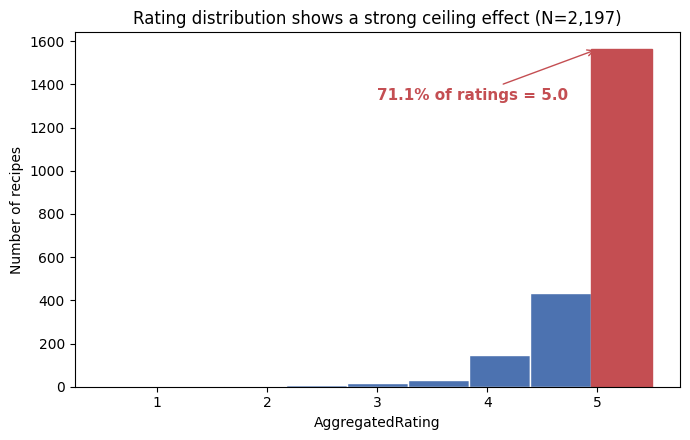

In [102]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,4.5))
counts, bins, patches = ax.hist(sub['AggregatedRating'], bins=9, range=(0.5,5.5),
                                 edgecolor='white', color='#4C72B0')
# highlight the 5.0 bar
patches[-1].set_color('#C44E52')

pct5 = (sub['AggregatedRating']==5.0).mean()*100
ax.annotate(f"{pct5:.1f}% of ratings = 5.0",
            xy=(5, counts[-1]), xytext=(3.0, counts[-1]*0.85),
            fontsize=11, fontweight='bold', color='#C44E52',
            arrowprops=dict(arrowstyle='->', color='#C44E52'))

ax.set_xlabel('AggregatedRating')
ax.set_ylabel('Number of recipes')
ax.set_title(f'Rating distribution shows a strong ceiling effect (N={len(sub):,})')
ax.set_xticks([1,2,3,4,5])
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150)
plt.show()

### Outlier Calories — liên hệ với RecipeServings missing

In [103]:
high_cal = sub[sub['Calories'] > 3000]
print("N Calories>3000:", len(high_cal))
missing_serv = high_cal['RecipeServings'].isna().sum()
print("Missing RecipeServings among those:", missing_serv, f"({missing_serv/len(high_cal)*100:.1f}%)")

has_serv = sub[sub['RecipeServings'].notna()]
no_serv = sub[sub['RecipeServings'].isna()]
print("\np95 Calories - has servings:", round(has_serv['Calories'].quantile(0.95), 0))
print("p95 Calories - no servings:", round(no_serv['Calories'].quantile(0.95), 0))

print("\nN sub with RecipeServings present:", sub['RecipeServings'].notna().sum())

N Calories>3000: 39
Missing RecipeServings among those: 36 (92.3%)

p95 Calories - has servings: 793.0
p95 Calories - no servings: 2753.0

N sub with RecipeServings present: 1418


## Phase 6 — Kết quả thực nghiệm

### 6.1 Category main effect (Kruskal-Wallis, N=1,429, k=19)

In [104]:
sub19 = sub[sub['RecipeCategory'].isin(cats19)].copy()
print("N:", len(sub19), "k categories:", sub19['RecipeCategory'].nunique())

groups = [g['AggregatedRating'].values for _, g in sub19.groupby('RecipeCategory')]
H, p = stats.kruskal(*groups)
k = len(groups)
n = len(sub19)
eps2 = (H - k + 1) / (n - k)
print(f"Kruskal-Wallis: H={H:.3f}, df={k-1}, p={p:.3f}, epsilon^2={eps2:.4f}")

p_category = p  # save for BH step below

N: 1429 k categories: 19
Kruskal-Wallis: H=21.803, df=18, p=0.241, epsilon^2=0.0027


### 6.2 Prep-time bucket effect (Fisher-combine Kruskal-Wallis, N=1,323, k=17)

In [105]:
sub19['PrepTimeMin'] = sub19['PrepTime'].apply(parse_iso)
sub19_p = sub19.dropna(subset=['PrepTimeMin']).copy()
print("N with PrepTime parsed:", len(sub19_p))

q1 = sub19_p['PrepTimeMin'].quantile(1/3)
q2 = sub19_p['PrepTimeMin'].quantile(2/3)
print(f"Tertile cutpoints: q1={q1}, q2={q2}")

def bucket(m):
    if m <= q1: return 'Low'
    elif m <= q2: return 'Mid'
    else: return 'High'
sub19_p['PrepBucket'] = sub19_p['PrepTimeMin'].apply(bucket)

pvals = []
total_n = 0
k_cats = 0
excluded = []
for c in sub19_p['RecipeCategory'].unique():
    g = sub19_p[sub19_p['RecipeCategory'] == c]
    bucket_counts = g['PrepBucket'].value_counts()
    if (bucket_counts < 5).any() or len(bucket_counts) < 2:
        excluded.append(c)
        continue
    groups_pt = [gg['AggregatedRating'].values for _, gg in g.groupby('PrepBucket')]
    H_pt, p_pt = stats.kruskal(*groups_pt)
    pvals.append(p_pt)
    total_n += len(g)
    k_cats += 1

stat = -2 * sum(np.log(pvals))
dfree = 2 * len(pvals)
p_comb = 1 - stats.chi2.cdf(stat, dfree)
print(f"\nFisher combine: chi2={stat:.3f}, df={dfree}, p={p_comb:.3f}, k={k_cats}, N={total_n}")
print("Excluded categories (bucket<5):", excluded)

p_preptime = p_comb  # save for BH step below

N with PrepTime parsed: 1429
Tertile cutpoints: q1=10.0, q2=15.0

Fisher combine: chi2=29.405, df=34, p=0.692, k=17, N=1323
Excluded categories (bucket<5): ['< 60 Mins', 'Beverages']


### 6.3 Nutrition dimension (Fisher-combine Mann-Whitney, N=898, k=18)

In [106]:
sub19_nutri = sub19[sub19['RecipeServings'].notna()].copy()
print("N with all 19 categories + RecipeServings:", len(sub19_nutri))

def fisher_combine_test(data, dim, exclude_cats=None, min_group=5):
    cats = data['RecipeCategory'].unique()
    if exclude_cats:
        cats = [c for c in cats if c not in exclude_cats]
    pvals, rs, weights = [], [], []
    for c in cats:
        g = data[data['RecipeCategory'] == c]
        med = g[dim].median()
        high = g[g[dim] > med]['AggregatedRating']
        low = g[g[dim] <= med]['AggregatedRating']
        if len(high) < min_group or len(low) < min_group:
            continue
        U, p_mw = stats.mannwhitneyu(high, low, alternative='two-sided')
        n1, n2 = len(high), len(low)
        r_mw = 1 - (2*U) / (n1*n2)
        pvals.append(p_mw)
        rs.append(r_mw)
        weights.append(n1 + n2)
    stat_f = -2 * sum(np.log(pvals))
    df_f = 2 * len(pvals)
    p_comb_f = 1 - stats.chi2.cdf(stat_f, df_f)
    weighted_r = sum(r*w for r, w in zip(rs, weights)) / sum(weights)
    return sum(weights), len(pvals), p_comb_f, weighted_r

nutrition_results = {}
for dim in ['SugarContent','SodiumContent','SaturatedFatContent']:
    n_d, k_d, p_d, r_d = fisher_combine_test(sub19_nutri, dim, min_group=5)
    print(f"{dim}: N={n_d}, k={k_d}, p_comb={p_d:.3f}, weighted_r={r_d:.3f}")
    nutrition_results[dim] = p_d

p_sugar = nutrition_results['SugarContent']      # save for BH step below
p_sodium = nutrition_results['SodiumContent']    # save for BH step below
p_satfat = nutrition_results['SaturatedFatContent']  # save for BH step below

N with all 19 categories + RecipeServings: 907
SugarContent: N=898, k=18, p_comb=0.514, weighted_r=-0.009
SodiumContent: N=898, k=18, p_comb=0.330, weighted_r=-0.003
SaturatedFatContent: N=898, k=18, p_comb=0.581, weighted_r=-0.033


### 6.4b %Rating=5.0 theo category x nhom high/low (vi du SodiumContent)

Doi chieu voi cau report 6.4: "Ty le dat-5.0 dao dong 50-90% o ca nhom cao lan thap moi dimension".

In [107]:
dim = 'SodiumContent'
rows = []
for c in sub19_nutri['RecipeCategory'].unique():
    g = sub19_nutri[sub19_nutri['RecipeCategory'] == c]
    med = g[dim].median()
    high = g[g[dim] > med]['AggregatedRating']
    low = g[g[dim] <= med]['AggregatedRating']
    if len(high) < 5 or len(low) < 5:
        continue
    pct5_high = (high == 5.0).mean() * 100
    pct5_low = (low == 5.0).mean() * 100
    rows.append({'category': c, 'n_high': len(high), 'pct5_high': pct5_high,
                  'n_low': len(low), 'pct5_low': pct5_low})

pct5_df = pd.DataFrame(rows).sort_values('category').reset_index(drop=True)
print(pct5_df.to_string(index=False, float_format='%.1f'))

all_pcts = list(pct5_df['pct5_high']) + list(pct5_df['pct5_low'])
print(f"\nRange tong hop (min-max qua tat ca category x nhom): {min(all_pcts):.1f}% - {max(all_pcts):.1f}%")

      category  n_high  pct5_high  n_low  pct5_low
     < 60 Mins      10       70.0     10      70.0
    Bar Cookie       8       75.0      9      66.7
     Beverages      29       82.8     31      83.9
        Breads      11       72.7     11      63.6
     Breakfast      32       84.4     32      71.9
       Chicken      27       55.6     27      74.1
Chicken Breast      27       63.0     27      59.3
       Dessert      63       71.4     63      63.5
  Drop Cookies       6       66.7      7      71.4
  Lunch/Snacks      52       78.8     53      66.0
          Meat      16       68.8     16      75.0
 One Dish Meal      47       51.1     47      70.2
           Pie      11       63.6     12      75.0
          Pork      19       84.2     19      73.7
        Potato      23       73.9     23      82.6
  Quick Breads      11       90.9     12      50.0
        Sauces       9       66.7     10     100.0
     Vegetable      44       63.6     44      72.7

Range tong hop (min-max qua ta

### 6.5 Benjamini-Hochberg (5 test)

In [108]:
from statsmodels.stats.multitest import multipletests

# Chained directly from the named variables set in the cells above (p_category from the
# Category-effect cell, p_preptime from the Prep-time Fisher-combine cell, p_sugar/p_sodium/
# p_satfat from the Nutrition cell) — not re-typed by hand. If an earlier cell's result
# changes, this cell updates automatically instead of silently going stale.
pvals_all = [p_category, p_preptime, p_sugar, p_sodium, p_satfat]
names_all = ['Category', 'PrepTime', 'Sugar', 'Sodium', 'SaturatedFat']

reject, p_adj, _, _ = multipletests(pvals_all, alpha=0.05, method='fdr_bh')
for name, p_raw, p_a, rej in zip(names_all, pvals_all, p_adj, reject):
    print(f"{name}: p_raw={p_raw:.3f}, p_adj={p_a:.3f}, reject={rej}")

Category: p_raw=0.241, p_adj=0.692, reject=False
PrepTime: p_raw=0.692, p_adj=0.692, reject=False
Sugar: p_raw=0.514, p_adj=0.692, reject=False
Sodium: p_raw=0.330, p_adj=0.692, reject=False
SaturatedFat: p_raw=0.581, p_adj=0.692, reject=False


### 6.6 Robustness — Category-effect

In [109]:
def run_kw(threshold, exclude_top_author=False, min_n=30):
    s = rated[rated['ReviewCount'] >= threshold].copy()
    if exclude_top_author:
        s = s[~s['AuthorId'].isin(top_authors)]
    s19 = s[s['RecipeCategory'].isin(cats19)]
    cc = s19['RecipeCategory'].value_counts()
    valid_cats = cc[cc >= min_n].index
    s19f = s19[s19['RecipeCategory'].isin(valid_cats)]
    groups_r = [g['AggregatedRating'].values for _, g in s19f.groupby('RecipeCategory')]
    k_r = len(groups_r)
    n_r = len(s19f)
    if k_r < 2:
        return n_r, k_r, None, None, None
    H_r, p_r = stats.kruskal(*groups_r)
    eps2_r = (H_r - k_r + 1) / (n_r - k_r) if n_r > k_r else np.nan
    return n_r, k_r, H_r, p_r, eps2_r

for th in [3, 5, 10]:
    res = run_kw(th)
    print(f"RC>={th}: N={res[0]}, k={res[1]}, H={res[2]:.3f}, p={res[3]:.3f}, eps2={res[4]:.4f}")

res = run_kw(3, exclude_top_author=True)
print(f"RC>=3, no top-author: N={res[0]}, k={res[1]}, H={res[2]:.3f}, p={res[3]:.3f}, eps2={res[4]:.4f}")

RC>=3: N=1429, k=19, H=21.803, p=0.241, eps2=0.0027
RC>=5: N=667, k=12, H=19.769, p=0.049, eps2=0.0134
RC>=10: N=142, k=4, H=2.479, p=0.479, eps2=-0.0038
RC>=3, no top-author: N=855, k=14, H=12.803, p=0.463, eps2=-0.0002


### 6.7 Robustness — Sodium-effect (RC≥5, loại top-author)

Đã robustness-check giới hạn (không đầy đủ như Category-effect — chỉ 2 điều kiện thay vì 4) theo quyết định phân bổ effort ở Phase 7.

In [110]:
def build_nutri(rc_thresh, exclude_top=False):
    s = rated[rated['ReviewCount'] >= rc_thresh].copy()
    if exclude_top:
        s = s[~s['AuthorId'].isin(top_authors)]
    s19 = s[s['RecipeCategory'].isin(cats19)]
    return s19[s19['RecipeServings'].notna()]

n_d, k_d, p_d, r_d = fisher_combine_test(build_nutri(5), 'SodiumContent', min_group=5)
print(f"Sodium, RC>=5: N={n_d}, k={k_d}, p_comb={p_d:.3f}, weighted_r={r_d:.3f}")

n_d2, k_d2, p_d2, r_d2 = fisher_combine_test(build_nutri(3, exclude_top=True), 'SodiumContent', min_group=5)
print(f"Sodium, RC>=3, no top-author: N={n_d2}, k={k_d2}, p_comb={p_d2:.3f}, weighted_r={r_d2:.3f}")

Sodium, RC>=5: N=499, k=16, p_comb=0.357, weighted_r=0.026
Sodium, RC>=3, no top-author: N=598, k=18, p_comb=0.661, weighted_r=-0.005


### Visualization — Sample size shrinkage across filtering stages

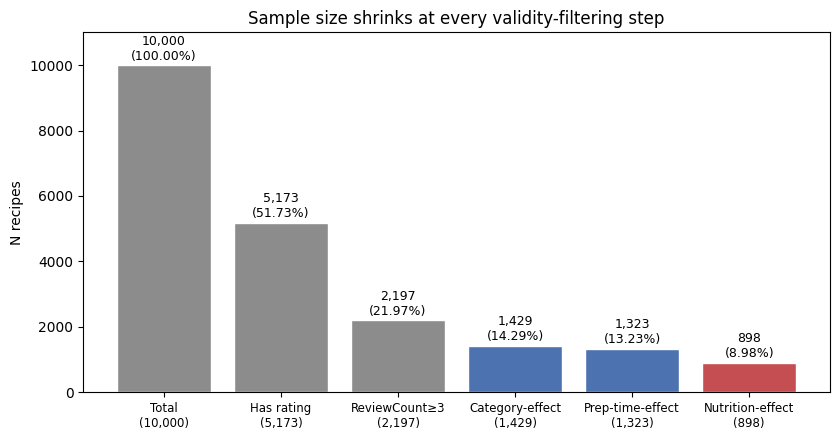

In [111]:
# N-shrinkage across filtering stages
stages = ['Total\n(10,000)', 'Has rating\n(5,173)', 'ReviewCount\u22653\n(2,197)',
          'Category-effect\n(1,429)', 'Prep-time-effect\n(1,323)', 'Nutrition-effect\n(898)']
values = [10000, 5173, 2197, 1429, 1323, 898]
colors = ['#8C8C8C','#8C8C8C','#8C8C8C','#4C72B0','#4C72B0','#C44E52']

fig, ax = plt.subplots(figsize=(8.5,4.5))
bars = ax.bar(stages, values, color=colors, edgecolor='white')
for b, v in zip(bars, values):
    ax.annotate(f"{v:,}\n({v/10000*100:.2f}%)", xy=(b.get_x()+b.get_width()/2, v),
                xytext=(0,4), textcoords='offset points', ha='center', fontsize=9)

ax.set_ylabel('N recipes')
ax.set_title('Sample size shrinks at every validity-filtering step')
ax.set_ylim(0, 11000)
plt.xticks(fontsize=8.5)
plt.tight_layout()
plt.savefig('n_shrinkage.png', dpi=150)
plt.show()

### Visualization — Effect size across all 5 tests

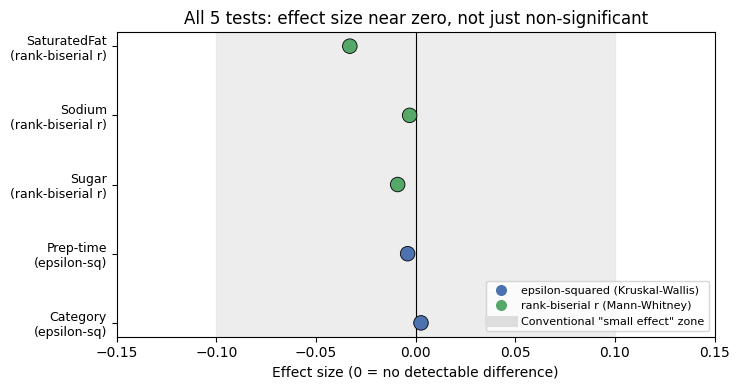

In [112]:
# Effect size across all 5 tests — consistently near zero
import numpy as np

tests = ['Category\n(epsilon-sq)', 'Prep-time\n(epsilon-sq)', 'Sugar\n(rank-biserial r)',
         'Sodium\n(rank-biserial r)', 'SaturatedFat\n(rank-biserial r)']
effect_sizes = [0.0027, -0.004, -0.009, -0.003, -0.033]
metric_type = ['epsilon-sq','epsilon-sq','rank-biserial r','rank-biserial r','rank-biserial r']
colors_pts = ['#4C72B0' if m=='epsilon-sq' else '#55A868' for m in metric_type]

fig, ax = plt.subplots(figsize=(7.5,4))
y_pos = np.arange(len(tests))
ax.axvspan(-0.1, 0.1, color='#DDDDDD', alpha=0.5, label='Conventional "small effect" zone')
ax.scatter(effect_sizes, y_pos, s=110, c=colors_pts, zorder=3, edgecolor='black', linewidth=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(tests, fontsize=9)
ax.set_xlim(-0.15, 0.15)
ax.set_xlabel('Effect size (0 = no detectable difference)')
ax.set_title('All 5 tests: effect size near zero, not just non-significant')

from matplotlib.lines import Line2D
legend_elems = [Line2D([0],[0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=9, label='epsilon-squared (Kruskal-Wallis)'),
                Line2D([0],[0], marker='o', color='w', markerfacecolor='#55A868', markersize=9, label='rank-biserial r (Mann-Whitney)'),
                Line2D([0],[0], color='#DDDDDD', lw=8, label='Conventional "small effect" zone')]
ax.legend(handles=legend_elems, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('effect_sizes.png', dpi=150)
plt.show()

## Phase 7-9 — Robustness Coverage & Evidence Synthesis

Robustness-matrix đầy đủ chỉ chạy cho Category-effect (test duy nhất có 1 threshold nominally significant ở RC≥5, không bền — xem 6.6). Sugar/SaturatedFat/Prep-time không chạy robustness bổ sung vì effect size đã ≈0 ở primary test — quyết định phân bổ effort theo trọng số finding.

**Evidence classification (tóm tắt từ Phase 6):**

| Finding | N | p (primary) | Evidence Strength |
|---|---|---|---|
| Category → Rating | 1,429 | 0.241 | Insufficient Evidence |
| Prep-time bucket → Rating | 1,323 | 0.692 | Insufficient Evidence |
| Nutrition (Sugar/Sodium/SaturatedFat) → Rating | 898 | 0.514/0.330/0.581 | Insufficient Evidence |

**0/3 finding đạt Robust Evidence** → No Action trên finding hiện tại (xem Final Memo trong report chính).